## IMPORTACIÓN DE LIBRERIAS Y MODULOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Configuración visual 
plt.style.use('ggplot')
sns.set_palette('Set2')

## CARGA DE DATOS

In [4]:
df = pd.read_csv('student_performance_500.csv')

In [5]:
df.shape

(500, 11)

In [6]:
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [7]:
df.dtypes

student_id               object
gender                   object
age                       int64
study_hours_per_week      int64
attendance_rate         float64
parent_education         object
internet_access          object
extracurricular          object
previous_score            int64
final_score               int64
passed                   object
dtype: object

In [8]:
num_datos_nulos = df.isnull().sum()
print("📊CONTEO DE DATOS NULOS:")
print("-" * 50)
print(num_datos_nulos)

📊CONTEO DE DATOS NULOS:
--------------------------------------------------
student_id              0
gender                  0
age                     0
study_hours_per_week    0
attendance_rate         0
parent_education        0
internet_access         0
extracurricular         0
previous_score          0
final_score             0
passed                  0
dtype: int64


In [9]:
df.duplicated().sum()

0

In [10]:
# Definir la función para contar valores atípicos
def contar_valores_atipicos(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    umbral_inferior = Q1 - 1.5 * IQR
    umbral_superior = Q3 + 1.5 * IQR
    valores_atipicos = ((columna < umbral_inferior) | (columna > umbral_superior)).sum()
    return valores_atipicos
# Lista de variables cuantitativas de tu dataset
variables_cuantitativas = ['age', 'study_hours_per_week','attendance_rate','previous_score','final_score']
# Aplicar la función a cada variable
print("📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):")
print("-" * 50)
for variable in variables_cuantitativas:
    num_valores_atipicos = contar_valores_atipicos(df[variable])
    print(f"{variable:25} → {num_valores_atipicos:5} valores atípicos")

print("-" * 50)
total_atipicos = sum([contar_valores_atipicos(df[var]) for var in variables_cuantitativas])
print(f"TOTAL de valores atípicos en todas las variables: {total_atipicos}")

📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):
--------------------------------------------------
age                       →     0 valores atípicos
study_hours_per_week      →     0 valores atípicos
attendance_rate           →     0 valores atípicos
previous_score            →     0 valores atípicos
final_score               →     0 valores atípicos
--------------------------------------------------
TOTAL de valores atípicos en todas las variables: 0


## ANÁLISIS EXPLORATORIO DE DATOS (EDA)

In [11]:
df.describe()

,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.978000,15.312000,76.380600,62.986000,55.980000
std,1.434445,8.568167,13.817681,18.937451,15.373754
min,15.000000,2.000000,50.200000,30.000000,20.000000
25%,16.000000,8.000000,64.475000,46.000000,45.000000
50%,17.000000,15.000000,76.500000,64.000000,56.000000
75%,18.000000,23.000000,88.525000,79.000000,68.000000
max,19.000000,30.000000,100.000000,95.000000,95.000000


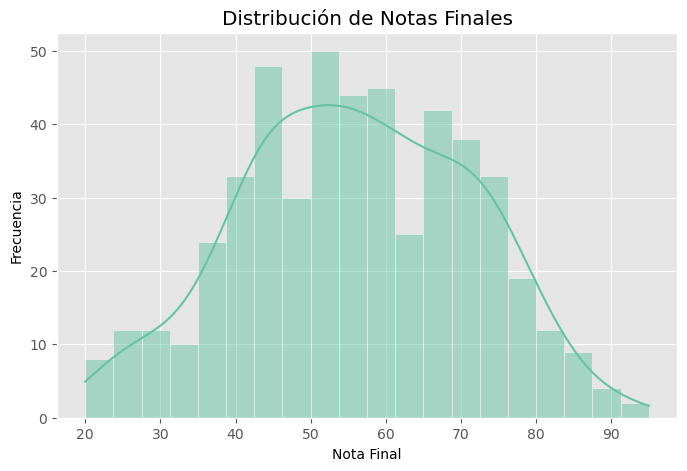

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='final_score',bins=20,kde=True)

plt.title('Distribución de Notas Finales')
plt.xlabel('Nota Final')
plt.ylabel('Frecuencia')
plt.show()

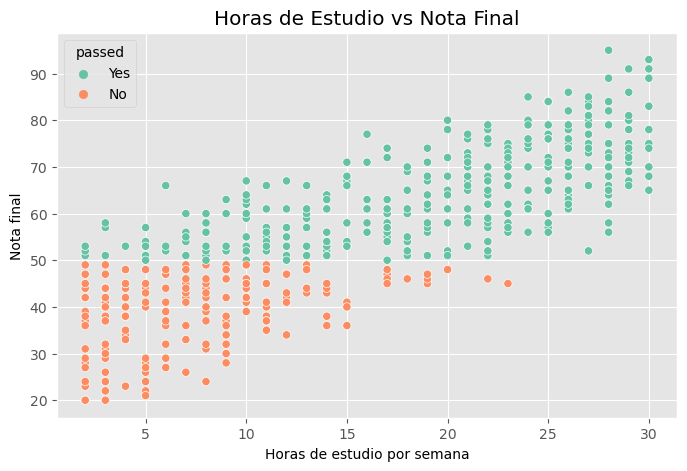

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='study_hours_per_week',y='final_score',hue='passed')

plt.title('Horas de Estudio vs Nota Final')
plt.xlabel('Horas de estudio por semana')
plt.ylabel('Nota final')
plt.show()

In [14]:
numeric_columns = ['age','study_hours_per_week','attendance_rate','previous_score','final_score']

correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,age,study_hours_per_week,attendance_rate,previous_score,final_score
age,1.000000,-0.055204,0.026155,-0.106613,-0.047819
study_hours_per_week,-0.055204,1.000000,-0.016038,-0.076127,0.803903
attendance_rate,0.026155,-0.016038,1.000000,-0.033069,0.240697
previous_score,-0.106613,-0.076127,-0.033069,1.000000,0.164958
final_score,-0.047819,0.803903,0.240697,0.164958,1.000000


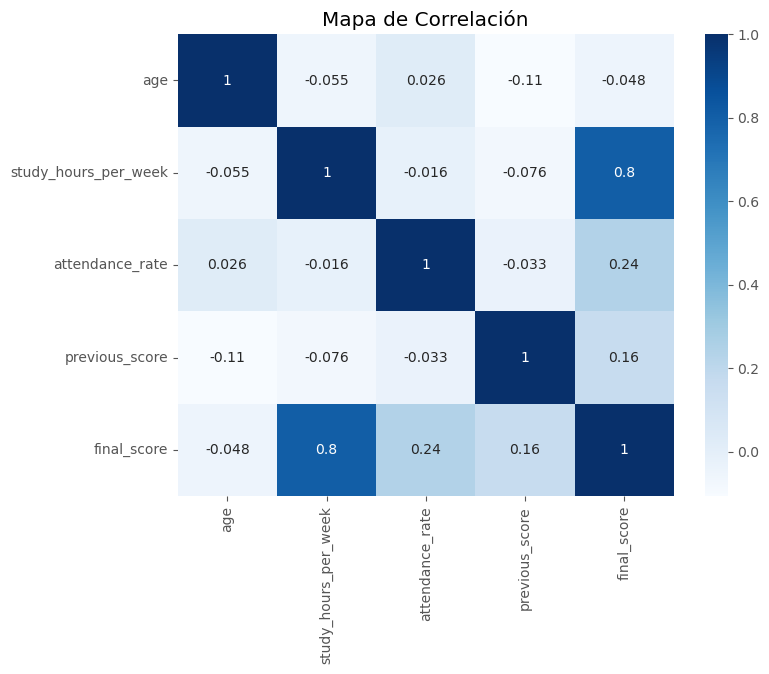

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap( correlation_matrix,annot=True, cmap='Blues')
plt.title('Mapa de Correlación')
plt.show()

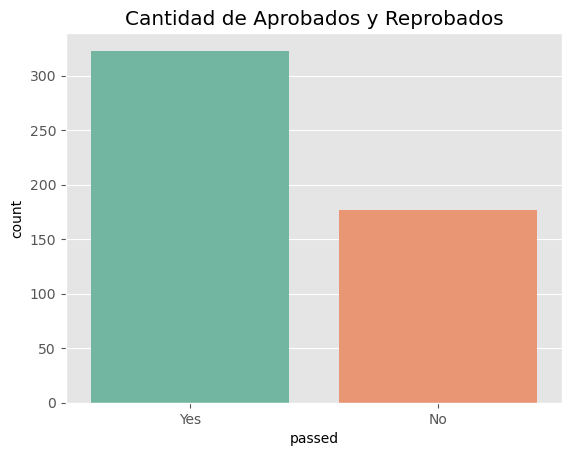

In [16]:
sns.countplot(data=df, x='passed')
plt.title('Cantidad de Aprobados y Reprobados')
plt.show()

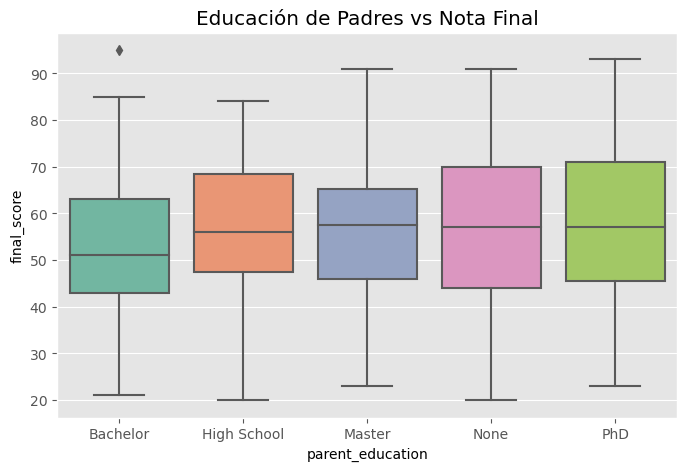

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot( data=df,x='parent_education',y='final_score')
plt.title('Educación de Padres vs Nota Final')
plt.show()

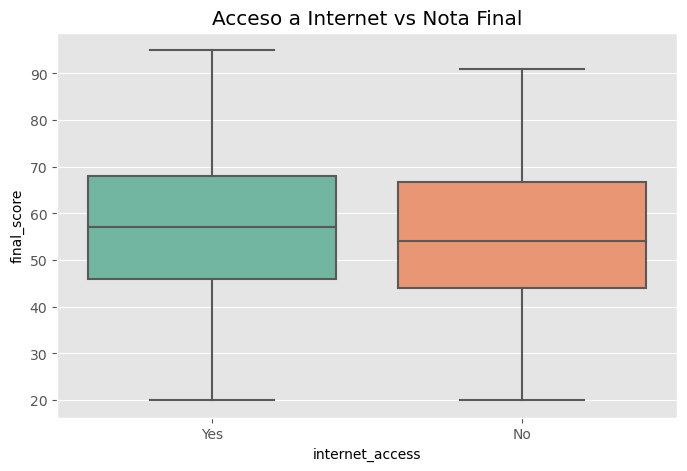

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='internet_access',y='final_score')

plt.title('Acceso a Internet vs Nota Final')
plt.show()

## PREPROCESAMIENTO

In [19]:
student_ids = df["student_id"]  #respaldo
# Eliminar ID
df = df.drop(columns='student_id')
# Variables categóricas
categorical_columns = ['gender','parent_education','internet_access','extracurricular', 'passed']
# Encoding
encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])
    
# VARIABLES
X = df.drop(columns=['passed', 'final_score'])

# Variable objetivo
y = df['passed']

## ENTRENAMIENTO DE MODELOS

In [20]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# ESCALADO
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODELO 1: REGRESIÓN LOGÍSTICA
lr_model = LogisticRegression()
# Entrenamiento
lr_model.fit(X_train_scaled, y_train)
# Predicción
y_pred_lr = lr_model.predict(X_test_scaled)
# Métricas
print("=== 📐 REGRESIÓN LOGÍSTICA ===")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_lr):.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== 📐 REGRESIÓN LOGÍSTICA ===
Accuracy  : 0.8600
Precision : 0.8378
Recall    : 0.9688
F1-score  : 0.8986

Matriz de confusión:
[[24 12]
 [ 2 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.77        36
           1       0.84      0.97      0.90        64

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100



In [21]:
# MODELO 2: RANDOM FOREST

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
# Entrenamiento
rf_model.fit(X_train_scaled, y_train)
# Predicción
y_pred_rf = rf_model.predict(X_test_scaled)
# Métricas
print("\n=== 🌲 RANDOM FOREST ===")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_rf):.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


=== 🌲 RANDOM FOREST ===
Accuracy  : 0.8300
Precision : 0.8219
Recall    : 0.9375
F1-score  : 0.8759

Matriz de confusión:
[[23 13]
 [ 4 60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.64      0.73        36
           1       0.82      0.94      0.88        64

    accuracy                           0.83       100
   macro avg       0.84      0.79      0.80       100
weighted avg       0.83      0.83      0.82       100



## PROBABILIDADES SOBRE EL TEST SET (ambos modelos)

In [22]:
prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

results_compare = X_test.copy()

# Valor real
results_compare["real"] = y_test.values
# Regresión Logística
results_compare["pred_lr"] = y_pred_lr
results_compare["prob_lr"] = prob_lr
# Random Forest
results_compare["pred_rf"] = y_pred_rf
results_compare["prob_rf"] = prob_rf

results_compare.head(10)

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,real,pred_lr,prob_lr,pred_rf,prob_rf
361,0,18,12,70.3,3,0,1,87,1,1,0.834346,1,0.78
73,0,19,27,96.0,4,0,0,64,1,1,0.998688,1,0.98
374,1,16,5,62.4,0,0,1,58,0,0,0.055989,0,0.25
155,1,16,15,79.4,3,1,0,69,1,1,0.835596,1,0.84
104,0,19,17,67.3,3,0,0,71,1,1,0.905797,1,0.88
394,1,16,22,64.6,1,0,1,69,1,1,0.959633,1,0.99
377,0,16,17,51.9,1,1,1,32,0,0,0.220018,1,0.62
124,1,18,2,81.0,3,0,1,38,0,0,0.034123,0,0.19
68,0,16,21,80.4,1,1,0,43,1,1,0.887321,1,0.96
450,0,15,4,63.1,2,1,1,73,0,0,0.065006,0,0.19


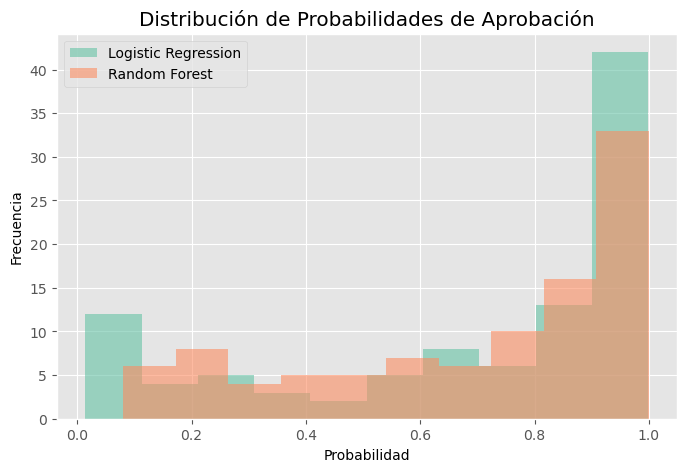

In [23]:
plt.figure(figsize=(8,5))
plt.hist(prob_lr, bins=10, alpha=0.6, label="Logistic Regression")
plt.hist(prob_rf, bins=10, alpha=0.6, label="Random Forest")

plt.title("Distribución de Probabilidades de Aprobación")
plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

In [24]:
disagreement = results_compare[
    results_compare["pred_lr"] != results_compare["pred_rf"]
]

disagreement

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,real,pred_lr,prob_lr,pred_rf,prob_rf
377,0,16,17,51.9,1,1,1,32,0,0,0.220018,1,0.62
371,1,17,14,56.9,0,1,1,78,1,1,0.646109,0,0.47
30,1,16,14,56.0,3,1,1,40,0,0,0.195428,1,0.56
475,1,15,6,96.4,3,1,0,92,1,1,0.694415,0,0.44
333,0,16,17,53.5,4,1,1,43,0,0,0.380323,1,0.69
148,1,15,10,72.2,4,0,0,83,0,1,0.627072,0,0.43
78,0,16,11,83.2,2,0,0,84,1,1,0.816112,0,0.46
341,0,16,3,96.1,4,0,0,84,1,0,0.452802,1,0.54
290,1,17,11,63.4,0,1,1,85,0,1,0.596914,0,0.42


## CONCLUSIONES

- El rendimiento de ambos modelos funcionan bien, pero Random Forest obtiene resultados más sólidos en general
- El análisis de probabilidades permitió observar diferencias importantes en la forma en que ambos modelos expresan incertidumbre. El modelo de Regresión Logística tiende a producir valores más extremos (cercanos a 0 o 1), mientras que Random Forest genera probabilidades más distribuidas, reflejando mayor flexibilidad ante casos intermedios.
- Se identificaron casos donde los modelos no coinciden en la predicción, lo cual representa estudiantes con perfiles límite o difíciles de clasificar. Estos casos son especialmente relevantes para análisis educativo, ya que pueden representar estudiantes en riesgo o en transición de rendimiento.

### FACTORES DE RIESGO + SISTEMA DE INTERPRETACIÓN

In [25]:
# Función para identificar factores de riesgo
def factores_riesgo(row):
    factores = []
    
    if row["study_hours_per_week"] < 10:
        factores.append("Bajas horas de estudio")
        
    if row["attendance_rate"] < 70:
        factores.append("Baja asistencia")
        
    if row["previous_score"] < 60:
        factores.append("Bajo rendimiento previo")
        
    if row["extracurricular"] == 0:
        factores.append("Sin actividades extracurriculares")
        
    if row["internet_access"] == 0:
        factores.append("Sin acceso a internet")
    
    return ", ".join(factores) if factores else "Sin factores críticos"


results_compare["student_id"] = student_ids.iloc[X_test.index].values

# Aplicar sistema al dataset
results_compare["riesgo"] = results_compare["prob_rf"].apply(
    lambda x: "🟢 Bajo riesgo" if x >= 0.7 else ("🟡 Riesgo medio" if x >= 0.4 else "🔴 Alto riesgo")
)

results_compare["factores"] = results_compare.apply(factores_riesgo, axis=1)
results_compare[["student_id", "real","pred_rf", "prob_rf", "riesgo", "factores"]].head(20)

,student_id,real,pred_rf,prob_rf,riesgo,factores
361,STU0362,1,1,0.78,🟢 Bajo riesgo,Sin acceso a internet
73,STU0074,1,1,0.98,🟢 Bajo riesgo,"Sin actividades extracurriculares, Sin acceso ..."
374,STU0375,0,0,0.25,🔴 Alto riesgo,"Bajas horas de estudio, Baja asistencia, Bajo ..."
155,STU0156,1,1,0.84,🟢 Bajo riesgo,Sin actividades extracurriculares
104,STU0105,1,1,0.88,🟢 Bajo riesgo,"Baja asistencia, Sin actividades extracurricul..."
394,STU0395,1,1,0.99,🟢 Bajo riesgo,"Baja asistencia, Sin acceso a internet"
377,STU0378,0,1,0.62,🟡 Riesgo medio,"Baja asistencia, Bajo rendimiento previo"
124,STU0125,0,0,0.19,🔴 Alto riesgo,"Bajas horas de estudio, Bajo rendimiento previ..."
68,STU0069,1,1,0.96,🟢 Bajo riesgo,"Bajo rendimiento previo, Sin actividades extra..."
450,STU0451,0,0,0.19,🔴 Alto riesgo,"Bajas horas de estudio, Baja asistencia"
